# OFF state recovery

In [19]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.miscellaneous as mi

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Define parameters

In [20]:
irradiance = 2.5
wavelength = 640
number_fluorophores = 2

In [21]:
system = fs.Cy5(number_fluorophores=number_fluorophores, distances=2, transitions=None,
                irradiance=irradiance, wavelength=wavelength, user=user, dstorm_parameters=dict(),
                remove=['CFRET', 'TFRET', 'HFRET'])

In [22]:
system.unique_transitions

,name,rate,trivial_name,abbreviation,fluorescence
id,,,,,
0,S0_S1,7.27e+06,excitation,EXC,False
1,S1_S0,2.70e+08,fluorescent emission,FLU,True
2,S1_T1,8.30e+05,intersystem crossing ST,ISCST,False
3,S1_S0,7.09e+08,internal conversion S,ICS,False
4,S1_Cis,2.00e+07,isomerization,ISO,False
5,Cis_S0,1.37e+05,backisomerization,BISO,False
6,T1_S0,5.00e+05,intersystem crossing TS,ISCTS,False
7,T1_OFF,9.60e+06,reduction,RED,False
8,OFF_S0,2.00e-01,oxidation,OX,False


(<Figure size 600x400 with 1 Axes>, <AxesSubplot:>)

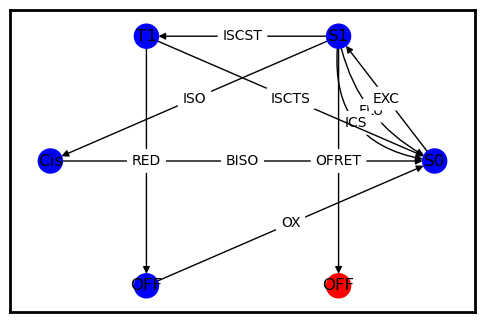

In [23]:
system.plot.network('circular')

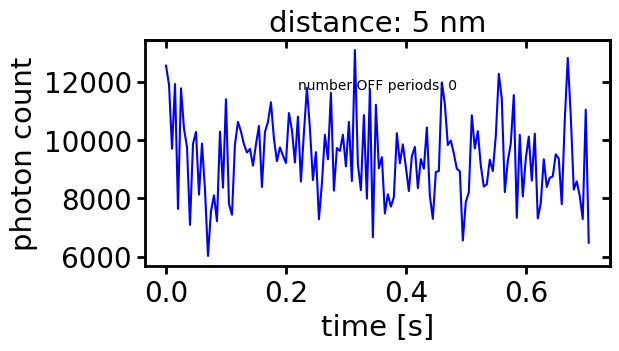

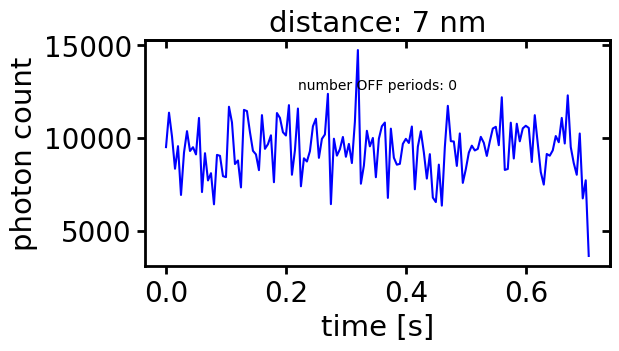

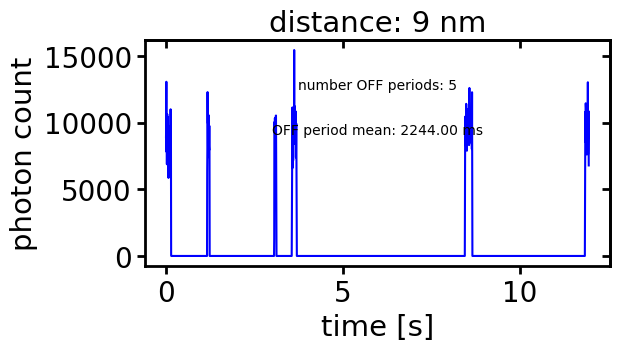

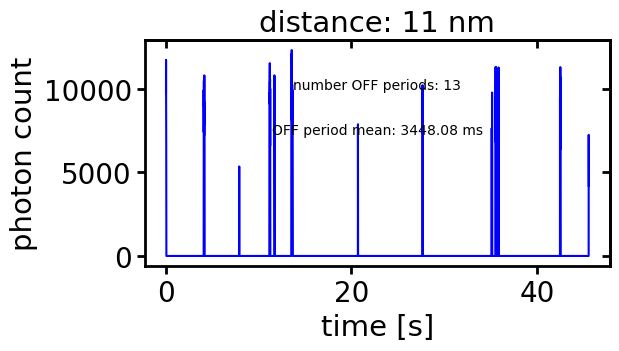

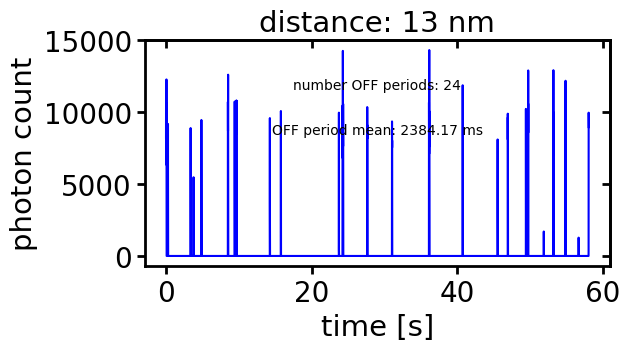

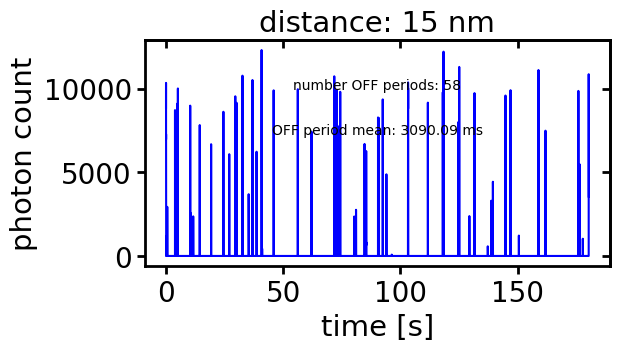

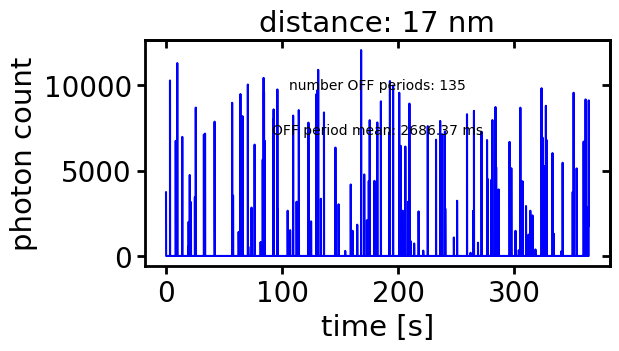

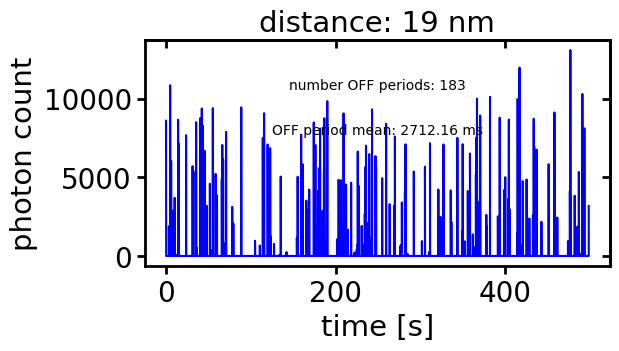

In [25]:
rng = np.random.default_rng(100)
distances = np.arange(5, 20, 2)
figures = []
for distance in distances:    
    system = fs.Cy5(number_fluorophores=number_fluorophores, distances=distance, transitions=None,
                irradiance=irradiance, wavelength=wavelength, user=user, dstorm_parameters=dict(),
                remove=['CFRET', 'TFRET', 'HFRET'])
    system.update_transitions({'RED': 1e5})
    system.simulate(n_steps=int(1e7), seed=rng)
    system.process()
    system.emitters(photon_collection_rate=0.01, resample="5ms", emccd_gain=100)
    fig, ax = system.plot.emission_events(time_series=True, title=f'distance: {distance} nm')
    ax[0, 0].text(0.5, 0.8, f'number OFF periods: {system.off_periods.size}', horizontalalignment='center', verticalalignment='center',
                  transform = ax[0, 0].transAxes)
    if system.off_periods.size > 0:
        ax[0, 0].text(0.5, 0.6, f'OFF period mean: {system.off_periods.mean()*5:.2f} ms', horizontalalignment='center', verticalalignment='center',
                  transform = ax[0, 0].transAxes)
    figures.append(fig)